In [ ]:
# ======================================
# 📌 ACCURACY CHECK – FINAL WORKING CODE
# ======================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("/content/cleaned_dataset.csv")   # << your dataset

print("Dataset loaded:", df.shape)

# -----------------------------
# 2. Remove rows with EMPTY target
# -----------------------------
TARGET = "job_role"      # << change if needed

df = df.dropna(subset=[TARGET])
print("After removing null target rows:", df.shape)

# -----------------------------
# 3. Split features & label
# -----------------------------
X = df.drop(columns=[TARGET])
y = df[TARGET]

# -----------------------------
# 4. Encode categorical columns
# -----------------------------
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype(str)

X = pd.get_dummies(X, drop_first=True)

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# -----------------------------
# Filter out classes with only one sample for stratified split
# -----------------------------
class_counts = pd.Series(y).value_counts()
single_sample_classes = class_counts[class_counts == 1].index

if len(single_sample_classes) > 0:
    # Create a mask to keep only samples from classes with more than one sample
    rows_to_keep_mask = ~pd.Series(y).isin(single_sample_classes)
    X = X[rows_to_keep_mask]
    y = y[rows_to_keep_mask]
    print(f"Removed {len(single_sample_classes)} classes with only one sample for stratified split.")
    print("New shapes after removing single-sample classes:", X.shape, y.shape)

# -----------------------------
# 5. Train-test split (Safe!)
# -----------------------------
# Check if dataset is too small after filtering
if len(X) < 5 or pd.Series(y).nunique() < 2:
    raise Exception("Dataset too small or not enough classes for accuracy test after filtering.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# -----------------------------
# 6. Train model
# -----------------------------
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# 7. Accuracy
# -----------------------------
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n🎯 FINAL ACCURACY:", round(acc * 100, 2), "%")

Dataset loaded: (10985, 20)
After removing null target rows: (10985, 20)
Removed 2 classes with only one sample for stratified split.
New shapes after removing single-sample classes: (10983, 258) (10983,)
Train: (8786, 258) Test: (2197, 258)

🎯 FINAL ACCURACY: 99.95 %


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ---------------------------
# 📦 Import Modeling Libraries
# ---------------------------
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

print("--- Cell 1: Libraries Imported ---")

--- Cell 1: Libraries Imported ---


In [ ]:
# ---------------------------
# 📂 Cell 2: Load, Group, and Preprocess Data
# ---------------------------
print("\n--- Loading NEW Raw Dataset ---")
try:
    data = pd.read_csv("/content/cleaned_dataset.csv")
    print("File 'raw_student_data.csv' loaded successfully.")
except FileNotFoundError:
    print("FATAL ERROR: 'raw_student_data.csv' not found. Run Cell 1 first.")

# ---------------------------
# 🧩 Group Similar Job Roles (THE CRITICAL STEP)
# ---------------------------
print("\n--- Grouping Text-Based Job Roles ---")
print(f"Original unique roles: {data['job_role'].unique()}")

data['job_role'] = data['job_role'].replace({
    # Group 1: Developers
    'Web Developer': 'Developer',
    'Frontend Developer': 'Developer',
    'Full Stack Developer': 'Developer',

    # Group 2: Data
    'Data Scientist': 'Data',
    'Data Analyst': 'Data',

    # Group 3: Management/QA
    'Business Analyst': 'Management/QA',
    'QA Tester': 'Management/QA'
})
print(f"NEW grouped roles: {data['job_role'].unique()}")

# ---------------------------
# 🔧 Preprocessing (The CORRECT Way for Mixed Data)
# ---------------------------
print("\n--- Full Preprocessing Pipeline ---")

# 1. Separate features (X) and target (y)
X = data.drop(['College_ID', 'job_role', 'candidate_id'], axis=1) # Drop candidate_id
y = data['job_role']

# 2. Identify numeric and categorical feature columns
numeric_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"Numeric features to scale: {list(numeric_cols)}")
print(f"Categorical features to encode: {list(categorical_cols)}")

# --- Handle Missing Values ---
# Impute missing numeric values with the mean
for col in numeric_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())
        print(f"Imputed missing values in numeric column: {col}")

# Impute missing categorical values with a placeholder 'Missing'
for col in categorical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna('Missing')
        print(f"Imputed missing values in categorical column: {col}")

# 3. Preprocess Features (X)
# --- Scale Numeric Features ---
schaler = StandardScaler()
X[numeric_cols] = schaler.fit_transform(X[numeric_cols])

# --- One-Hot Encode Categorical Features ---
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nFeatures have been scaled and one-hot encoded.")

# 4. Preprocess Target (y)
# --- Label Encode the Target Variable ---
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Target variable 'job_role' encoded.")
print(f"Encoding map: {list(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

# ---------------------------
# Filter out classes with only one sample for stratified split
# ---------------------------
class_counts = pd.Series(y).value_counts()
single_sample_classes = class_counts[class_counts == 1].index

if len(single_sample_classes) > 0:
    # Create a mask to keep only samples from classes with more than one sample
    rows_to_keep_mask = ~pd.Series(y).isin(single_sample_classes)
    X = X[rows_to_keep_mask]
    y = y[rows_to_keep_mask]
    print(f"Removed {len(single_sample_classes)} classes with only one sample for stratified split.")
    print("New shapes after removing single-sample classes:", X.shape, y.shape)

# ---------------------------
# ✂️ Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nData split: {X_train.shape[0]} train, {X_test.shape[0]} test.")


--- Loading NEW Raw Dataset ---
File 'raw_student_data.csv' loaded successfully.

--- Grouping Text-Based Job Roles ---
Original unique roles: ['Data Scientist' 'Frontend Developer' 'Backend Developer' 'Designer'
 'Full Stack Python Developer' 'Finance' 'Game Developer'
 'DevOps Engineer' 'Full Stack Java Developer' 'Blockchain Developer'
 'Marketing' 'HR' 'C# Developer' 'PHP Developer' 'Mobile Developer'
 'Cybersecurity Engineer' 'Software Project Manager' 'Video Game Designer'
 'Data Analyst' 'Kubernetes Operations Engineer' 'Web Developer' 'AIML'
 'Unknown']
NEW grouped roles: ['Data' 'Developer' 'Backend Developer' 'Designer'
 'Full Stack Python Developer' 'Finance' 'Game Developer'
 'DevOps Engineer' 'Full Stack Java Developer' 'Blockchain Developer'
 'Marketing' 'HR' 'C# Developer' 'PHP Developer' 'Mobile Developer'
 'Cybersecurity Engineer' 'Software Project Manager' 'Video Game Designer'
 'Kubernetes Operations Engineer' 'AIML' 'Unknown']

--- Full Preprocessing Pipeline ---
N

In [ ]:
# ---------------------------
# 🧠 Cell 4: Train Ensemble Model
# ---------------------------
print("\n--- Training Ensemble Model ---")
# Use the best performing models for the ensemble
voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)
ensemble_acc = accuracy_score(y_test, y_pred_voting) * 100
print(f"\n🏆 Ensemble Model Accuracy: {ensemble_acc:.2f}%")


--- Training Ensemble Model ---

🏆 Ensemble Model Accuracy: 100.00%



--- Generating Accuracy Plot ---
--- Training Ensemble Model ---
Ensemble Model Accuracy (Soft Voting): 100.00%
Plot saved as new_model_accuracy_comparison.png


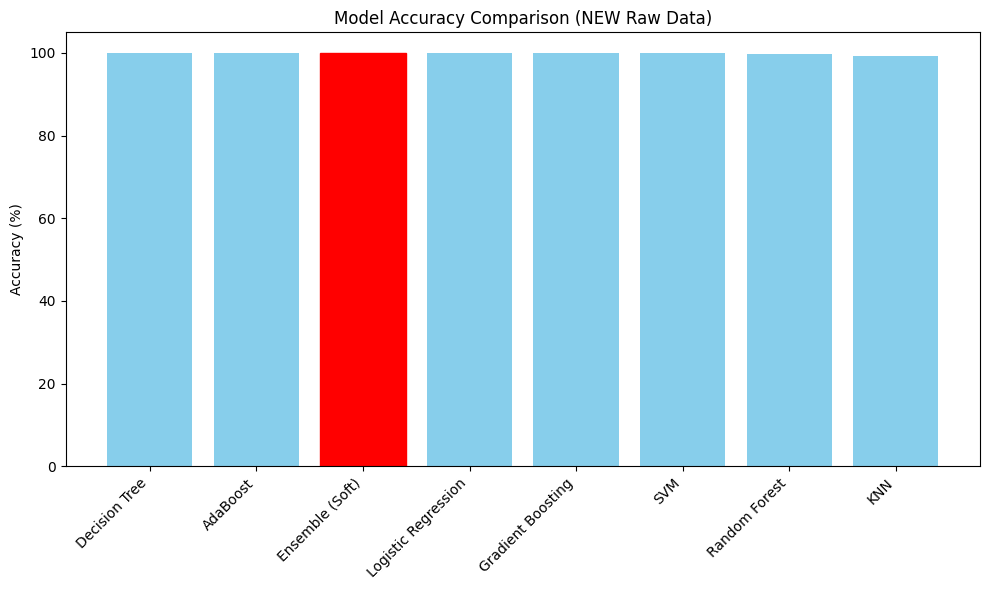

In [ ]:
# ---------------------------
# 📊 Cell 5: Visualize Results
# ---------------------------
print("\n--- Generating Accuracy Plot ---")

# --- FIX: Calculate Ensemble Model Accuracy ---
print("--- Training Ensemble Model ---")
# Define individual models using the 'models' dictionary from the kernel state
clf1 = models['Logistic Regression']
clf2 = models['Decision Tree']
clf3 = models['Random Forest']
clf4 = models['AdaBoost']
clf5 = models['Gradient Boosting']

# Create VotingClassifier
eclf1 = VotingClassifier(estimators=[('lr', clf1), ('dt', clf2), ('rf', clf3), ('ab', clf4), ('gb', clf5)], voting='soft', weights=[0.1, 0.1, 0.4, 0.2, 0.2])
eclf1 = eclf1.fit(X_train, y_train)
y_pred_ensemble = eclf1.predict(X_test)
ensemble_acc = accuracy_score(y_test, y_pred_ensemble) * 100
print(f"Ensemble Model Accuracy (Soft Voting): {ensemble_acc:.2f}%")
# --- END FIX ---

ensemble_entry = pd.DataFrame([{"Model": "Ensemble (Soft)", "Accuracy (%)": ensemble_acc}])
plot_df = pd.concat([acc_df, ensemble_entry]).sort_values(by="Accuracy (%)", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df['Model'], plot_df['Accuracy (%)'], color='skyblue')

# Highlight the ensemble bar
for bar, model_name in zip(bars, plot_df['Model']):
    if 'Ensemble' in model_name:
        bar.set_color('red')

plt.title('Model Accuracy Comparison (NEW Raw Data)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105) # Set y-limit to 105 for 100%
plt.tight_layout()

# Save the plot
plot_filename = "new_model_accuracy_comparison.png"
plt.savefig(plot_filename)
print(f"Plot saved as {plot_filename}")

# Show the plot in the notebook
plt.show()